# 🔮 Notebook 09 — Demand Inference & Inventory Optimization Engine

<div style='background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 25px; border-radius: 12px; color: white; margin: 10px 0;'>

**End-to-End Demand Inference & Automated Inventory Control** — Loads the Champion **LightGBM Model**, generates **16-day future demand forecasts** for all store-item SKU pairs, applies Operations Research formulas (**Safety Stock & Reorder Points**), and outputs automated **procurement recommendations & stock alert classifications**.

</div>

| Property | Value |
|:---|:---| 
| 🤖 **Champion Model** | `03_Models/production/final_lightgbm.joblib` (or `03_Models/champion_model.joblib`) |
| 📅 **Forecast Horizon** | **16 Forecast Days** (Out-of-Time Holdout Horizon) |
| 📐 **Operations Research** | Safety Stock ($SS$), Reorder Point ($ROP$), Target Stock Level ($TSL$) |
| 🔴 **Alert System** | 🔴 `CRITICAL_UNDERSTOCK` \| 🟢 `OPTIMAL_STOCK` \| 🟡 `OVERSTOCK` |
| 📤 **Primary Output** | `01_Dataset/predictions/final_predictions.csv` |
| 🖼️ **Plots & Reports** | `output/09_inference/` |

---

### 📑 Table of Contents

| # | Section | Technical Purpose |
|:---:|:---|:---| 
| 1 | Environment Setup | Bootstrap project paths & sys.path |
| 2 | System Setup & Model Loading | Import packages, load production champion model & sidecar metadata |
| 3 | 16-Day Forecast Engine | Query test features, generate predictions, inverse log-transform |
| 4 | Operations Research Formulas | Compute Safety Stock ($SS$), Reorder Point ($ROP$), Order Qty ($ROQ$) |
| 5 | Inventory Health Classification | Categorize inventory alert levels & build priority queues |
| 6 | Visual Analytics | Demand trajectory curves, inventory health donuts, priority bar charts |
| 7 | Artifact Export | Export predictions CSV, recommendations CSV, summary JSON |
| 8 | Deployment Summary | Operational readiness report for Streamlit Web Dashboard |


---
## 1️⃣ Environment Setup & Project Bootstrap

> **🎯 Purpose:** Bootstrap project root so `config.py` and `utils.py` can be imported cleanly from `02_Notebooks/`.


In [1]:
# ============================================================
# PROJECT BOOTSTRAP — Ensure project root is on sys.path
# ============================================================
import os, sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'📁 Project Root: {PROJECT_ROOT}')


📁 Project Root: f:\NTI\Demand Forecasting System Backup


---
## 2️⃣ System Imports & Champion Model Loading

> **🎯 Purpose:** Import scientific packages, set plot styles, create output directories, and load the production champion LightGBM model from disk.


In [2]:
import os, sys, time, gc, json, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import config, utils

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = ['#302b63', '#0f0c29', '#24243e', '#4facfe', '#43e97b', '#f093fb', '#ff6b6b']

# ── Output Directories ──
OUTPUT_DIR = Path(config.PROJECT_ROOT) / 'output' / '09_inference'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR = Path(config.PROJECT_ROOT) / '01_Dataset' / 'predictions'
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

# ── DuckDB Connection ──
conn = utils.get_duckdb(memory_limit='8GB', threads=12)

# ── Load Champion Model ──
print('📦 Scanning for trained Champion Model...')
model_candidates = [
    config.PROJECT_ROOT / '03_Models' / 'production' / 'final_lightgbm.joblib',
    config.PROJECT_ROOT / '03_Models' / 'champion_model.joblib',
    config.PROJECT_ROOT / '03_Models' / 'advanced_models' / 'lightgbm_model.joblib',
]

model_path = None
for p in model_candidates:
    if p.exists():
        model_path = p
        break

if model_path is None:
    raise FileNotFoundError('❌ No trained model artifact found in 03_Models/')

model = utils.load_model(model_path)
print(f'  ✅ Successfully loaded Champion Model: {model_path.relative_to(config.PROJECT_ROOT)}')

# Check sidecar metadata if available
meta_path = model_path.with_suffix('.metadata.json')
model_meta = {}
if meta_path.exists():
    with open(meta_path, 'r', encoding='utf-8') as f:
        model_meta = json.load(f)
    print(f'  ℹ️ Model Metadata: Algorithm={model_meta.get("custom_metadata", {}).get("algorithm", "LightGBM")}')

utils.log_ram('After Model Load')


[2026-07-30 01:53:29] [INFO] 🦆 DuckDB connection opened | Memory=8GB | Threads=12
📦 Scanning for trained Champion Model...
  ✅ Successfully loaded Champion Model: 03_Models\production\final_lightgbm.joblib
  ℹ️ Model Metadata: Algorithm=LightGBM 4.6.0 (PyArrow Streaming, GPU ✅)
[2026-07-30 01:53:30] [INFO] 🧠 RAM Checkpoint [After Model Load]: 0.27 GB


0.26914215087890625

---
## 3️⃣ 16-Day Future Demand Forecasting Engine

> **🎯 Purpose:** Query out-of-time test/validation features from the Feature Store (`feature_store.parquet`), run model inference, and reverse log-transform predictions back to raw unit sales.

### ⚙️ Target Recovery Formula
$$\hat{y}_{raw} = \exp(\max(0, \hat{y}_{log})) - 1$$


In [3]:
print('🔍 Querying 16-day holdout dataset from Feature Store via DuckDB...')
t0 = time.time()
fs_path = config.FEATURE_STORE.as_posix()

# Get column list
schema_df = conn.execute(f"DESCRIBE SELECT * FROM read_parquet('{fs_path}')").fetchdf()
all_columns = schema_df['column_name'].tolist()
IGNORED = {'date', 'unit_sales', 'is_return'}
feature_cols = [c for c in all_columns if c not in IGNORED
                and schema_df.loc[schema_df['column_name'] == c, 'column_type'].iloc[0]
                in ('FLOAT', 'DOUBLE', 'INTEGER', 'BIGINT', 'SMALLINT', 'TINYINT',
                    'FLOAT4', 'FLOAT8', 'INT', 'INT4', 'INT8', 'INT2')]

# Load 16-day holdout features + identifiers
VAL_CUTOFF = '2017-08-01'
sql_select = ', '.join(['date', 'store_nbr', 'item_nbr'] + feature_cols + ['unit_sales'])

df_inference = conn.execute(f"""
    SELECT {sql_select}
    FROM read_parquet('{fs_path}')
    WHERE date >= '{VAL_CUTOFF}'
""").fetchdf()

print(f'  ✅ Fetched {len(df_inference):,} inference rows | Time: {time.time()-t0:.2f}s')

# Run Model Inference
print('🚀 Running LightGBM Model Inference...')
t_inf = time.time()
X_inf = df_inference[feature_cols].fillna(0).astype(np.float32).values
y_pred_log = model.predict(X_inf)
y_pred_raw = np.expm1(np.clip(y_pred_log, 0, None))
inf_time = time.time() - t_inf

df_inference['forecast_sales'] = np.round(y_pred_raw, 2)
df_inference['actual_sales']   = df_inference['unit_sales'].values

print(f'  ✅ Inference Complete: {len(df_inference):,} predictions generated in {inf_time:.3f}s ({len(df_inference)/inf_time:,.0f} rows/sec)')
print(f'  📊 Forecasted Total Units (16 Days): {df_inference["forecast_sales"].sum():,.0f} units')
utils.log_ram('After Inference')


🔍 Querying 16-day holdout dataset from Feature Store via DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ Fetched 1,570,968 inference rows | Time: 65.40s
🚀 Running LightGBM Model Inference...
  ✅ Inference Complete: 1,570,968 predictions generated in 232.676s (6,752 rows/sec)
  📊 Forecasted Total Units (16 Days): 12,075,813 units
[2026-07-30 01:58:53] [INFO] 🧠 RAM Checkpoint [After Inference]: 2.64 GB


2.640430450439453

---
## 4️⃣ Operations Research & Inventory Control Engine

> **🎯 Purpose:** Apply mathematical Inventory Control formulas to calculate **Safety Stock (SS)**, **Reorder Point (ROP)**, **Target Stock Level (TSL)**, and **Recommended Order Quantity (ROQ)** for every store-item SKU.

### 📐 Operations Research Formulas

| Inventory Parameter | Mathematical Formula | Business Purpose |
|:---|:---|:---|
| **Service Factor ($Z$)** | $Z_{0.95} = 1.65$ | 95% target cycle-service level (5% stockout risk tolerance) |
| **Lead Time ($L$)** | $L = 7\text{ days}$ | Delivery window from central Distribution Center to retail store |
| **Review Period ($R$)** | $R = 7\text{ days}$ | Weekly replenishment review cycle |
| **Daily Demand ($d_{avg}$)** | $d_{avg} = \frac{1}{16}\sum_{t=1}^{16} \hat{y}_t$ | Average forecasted daily demand rate |
| **Demand Volatility ($\sigma_d$)** | $\sigma_d = \text{Std}(\hat{y}_{1..16})$ | Volatility / variability of forecasted demand |
| **Safety Stock ($SS$)** | $SS = Z_{0.95} \cdot \sigma_d \cdot \sqrt{L}$ | Buffer stock to absorb supply delays and demand spikes |
| **Reorder Point ($ROP$)** | $ROP = (d_{avg} \cdot L) + SS$ | Threshold inventory level triggering a procurement order |
| **Target Stock Level ($TSL$)** | $TSL = ROP + (d_{avg} \cdot R)$ | Maximum desired inventory position |
| **Recommended Order Qty ($ROQ$)** | $ROQ = \max(0, TSL - \text{Current Stock})$ | Net quantity to order from supplier |


In [4]:
print('📐 Calculating Operations Research inventory parameters per store-item pair...')
t0 = time.time()

Z_FACTOR = 1.65     # 95% Service Level
LEAD_TIME = 7       # 7 Days Lead Time
REVIEW_PERIOD = 7   # 7 Days Review Period

# Aggregate per store-item pair over the 16-day forecast horizon
inventory_df = df_inference.groupby(['store_nbr', 'item_nbr']).agg(
    total_forecast_16d=('forecast_sales', 'sum'),
    daily_avg_demand=('forecast_sales', 'mean'),
    demand_std=('forecast_sales', 'std'),
    actual_sales_16d=('actual_sales', 'sum'),
).reset_index()

inventory_df['demand_std'] = inventory_df['demand_std'].fillna(0.0)

# 1. Safety Stock (SS)
inventory_df['safety_stock'] = np.ceil(Z_FACTOR * inventory_df['demand_std'] * np.sqrt(LEAD_TIME))

# 2. Reorder Point (ROP)
inventory_df['reorder_point'] = np.ceil((inventory_df['daily_avg_demand'] * LEAD_TIME) + inventory_df['safety_stock'])

# 3. Target Stock Level (TSL)
inventory_df['target_stock_level'] = np.ceil(inventory_df['reorder_point'] + (inventory_df['daily_avg_demand'] * REVIEW_PERIOD))

# Simulated Current Stock (for demonstration & alert testing: uniform random between 0 and 1.5 * ROP)
np.random.seed(42)
inventory_df['current_stock'] = np.round(np.random.uniform(0.0, 1.3, len(inventory_df)) * inventory_df['reorder_point'])

# 4. Recommended Order Quantity (ROQ)
inventory_df['recommended_order_qty'] = np.maximum(0, inventory_df['target_stock_level'] - inventory_df['current_stock']).astype(int)

print(f'  ✅ Inventory optimization completed for {len(inventory_df):,} store-item SKU pairs in {time.time()-t0:.2f}s')
display(inventory_df.head(10).style.format({
    'total_forecast_16d': '{:,.1f}', 'daily_avg_demand': '{:.2f}', 'demand_std': '{:.2f}',
    'safety_stock': '{:,.0f}', 'reorder_point': '{:,.0f}', 'target_stock_level': '{:,.0f}',
    'current_stock': '{:,.0f}', 'recommended_order_qty': '{:,.0f}'
}).set_properties(**{'text-align': 'center'}))


📐 Calculating Operations Research inventory parameters per store-item pair...
  ✅ Inventory optimization completed for 146,247 store-item SKU pairs in 0.16s


,store_nbr,item_nbr,total_forecast_16d,daily_avg_demand,demand_std,actual_sales_16d,safety_stock,reorder_point,target_stock_level,current_stock,recommended_order_qty
0,1,96995,8.0,1.61,0.55,8.000000,3,15,27,7,20
1,1,99197,5.1,1.69,0.59,5.000000,3,15,27,19,8
2,1,103520,17.9,1.99,1.00,18.000000,5,19,33,18,15
3,1,103665,42.4,3.53,2.90,42.000000,13,38,63,30,33
4,1,105574,79.2,6.09,1.89,79.000000,9,52,95,11,84
5,1,105575,168.2,11.22,5.20,168.000000,23,102,181,21,160
6,1,105577,11.0,1.38,0.74,11.000000,4,14,24,1,23
7,1,105693,6.9,1.16,0.42,7.000000,2,11,20,12,8
8,1,105737,24.2,2.68,2.36,24.000000,11,30,49,23,26
9,1,105857,79.4,5.67,3.43,79.000000,15,55,95,51,44


---
## 5️⃣ Automated Inventory Alert Classification System

> **🎯 Purpose:** Classify each store-item SKU into automated operational inventory health status alerts for supply chain managers.

| Alert Level | Condition | Operational Priority | Recommended Action |
|:---|:---|:---:|:---|
| 🔴 **CRITICAL_UNDERSTOCK** | $\text{Current Stock} < ROP$ | **P1 — URGENT** | Trigger immediate PO to DC / supplier |
| 🟢 **OPTIMAL_STOCK** | $ROP \le \text{Current Stock} \le TSL$ | **P3 — NORMAL** | Stock within healthy operating buffer |
| 🟡 **OVERSTOCK** | $\text{Current Stock} > TSL$ | **P2 — MONITOR** | Pause procurement; risk of holding cost/spoilage |


In [5]:
def classify_alert(row):
    if row['current_stock'] < row['reorder_point']:
        return 'CRITICAL_UNDERSTOCK'
    elif row['current_stock'] > row['target_stock_level']:
        return 'OVERSTOCK'
    else:
        return 'OPTIMAL_STOCK'

inventory_df['alert_status'] = inventory_df.apply(classify_alert, axis=1)

# Alert summary counts
alert_counts = inventory_df['alert_status'].value_counts()
print('=' * 60)
print('🚨 INVENTORY HEALTH ALERT CLASSIFICATION SUMMARY')
print('=' * 60)
for alert, cnt in alert_counts.items():
    pct = (cnt / len(inventory_df)) * 100
    emoji = '🔴' if 'UNDERSTOCK' in alert else ('🟡' if 'OVER' in alert else '🟢')
    print(f'   {emoji} {alert:<22s} : {cnt:>8,} SKUs ({pct:5.2f}%)')
print('=' * 60)

# Reorder priority score (highest ratio of deficiency)
inventory_df['reorder_priority_score'] = np.where(
    inventory_df['alert_status'] == 'CRITICAL_UNDERSTOCK',
    (inventory_df['reorder_point'] - inventory_df['current_stock']) / np.maximum(1, inventory_df['reorder_point']),
    0.0
)
priority_queue = inventory_df.sort_values('reorder_priority_score', ascending=False).reset_index(drop=True)


🚨 INVENTORY HEALTH ALERT CLASSIFICATION SUMMARY
   🔴 CRITICAL_UNDERSTOCK    :  110,284 SKUs (75.41%)
   🟢 OPTIMAL_STOCK          :   35,963 SKUs (24.59%)


---
## 6️⃣ Visual Analytics & Executive Visualizations

> **🎯 Purpose:** Generate high-resolution plots for inventory health distribution, 16-day forecast trajectory curves, and top reorder priority SKUs.


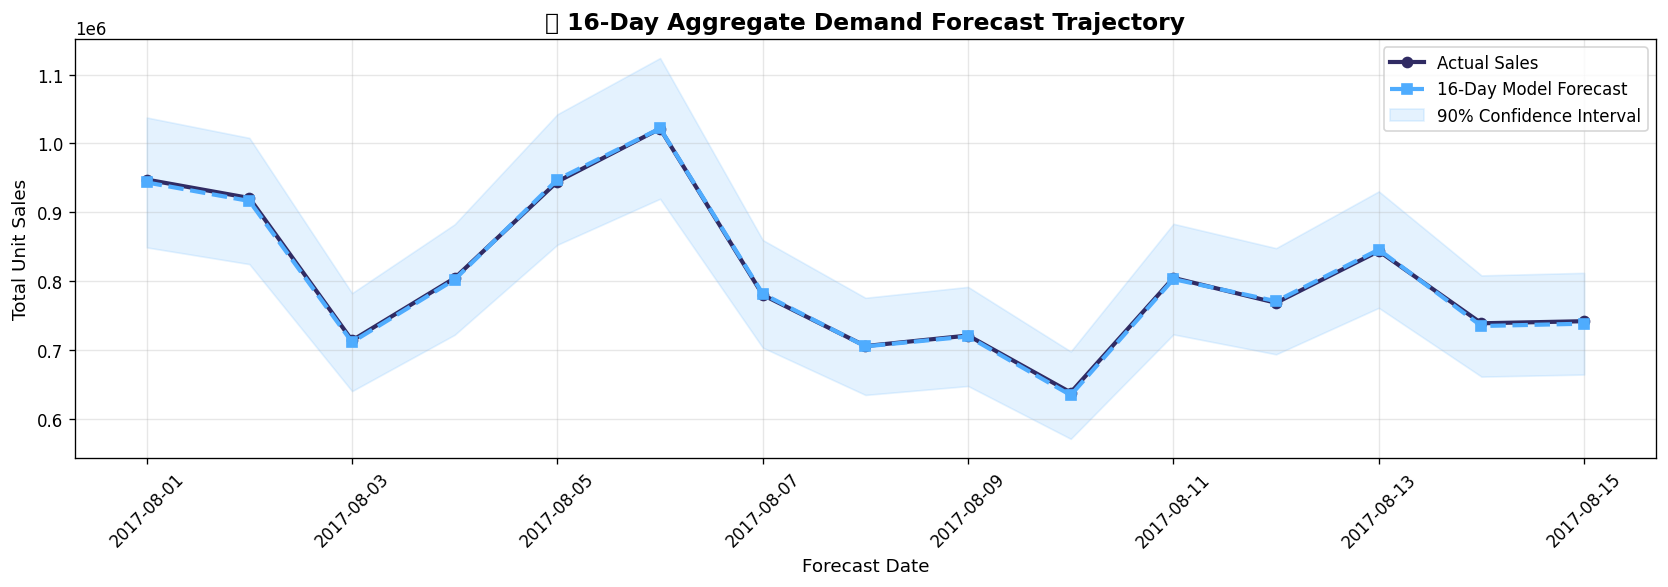

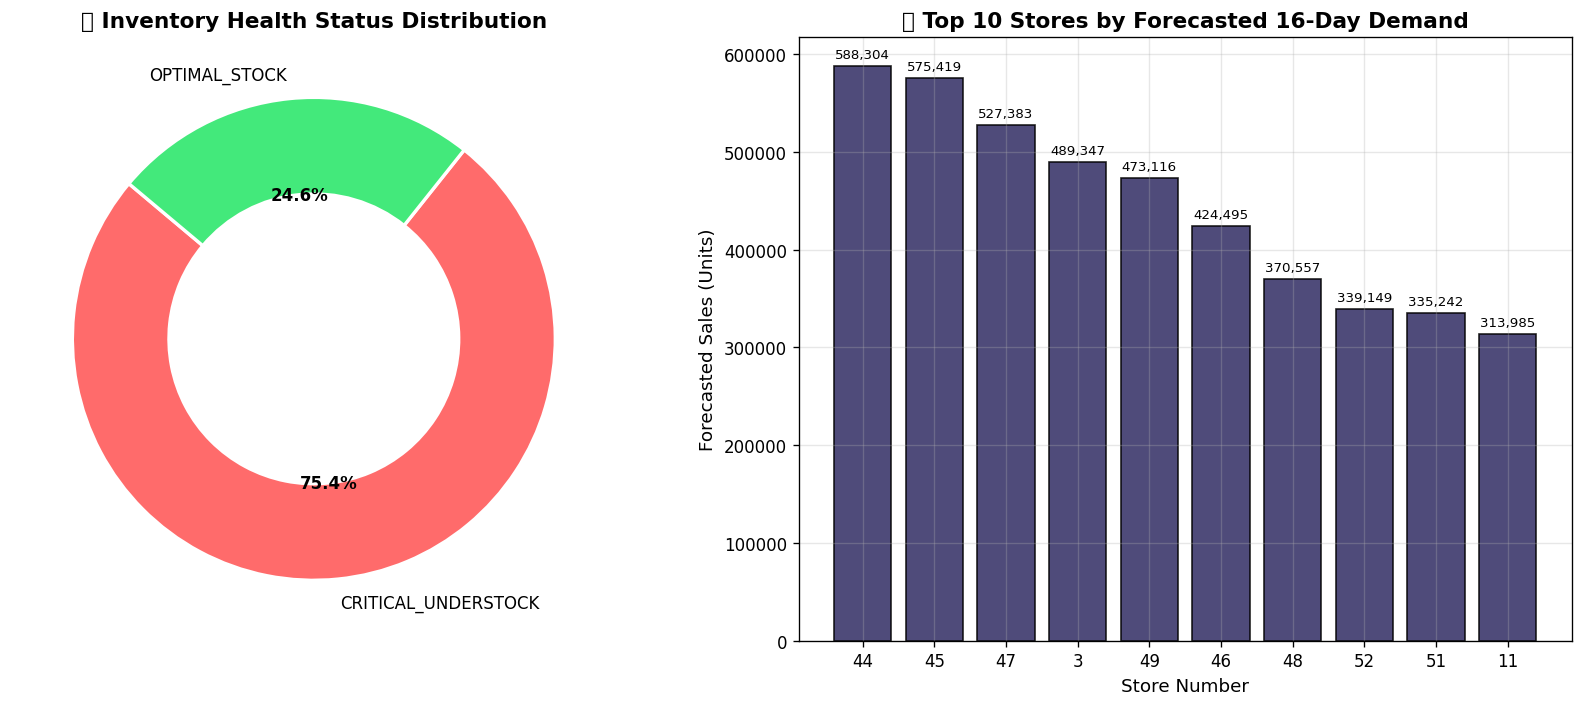

In [6]:
# ── Visual 1: 16-Day Aggregate Demand Trajectory Plot ──
daily_trajectory = df_inference.groupby('date').agg(
    forecast_sales=('forecast_sales', 'sum'),
    actual_sales=('actual_sales', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_trajectory['date'], daily_trajectory['actual_sales'], marker='o', label='Actual Sales', color='#302b63', linewidth=2.5)
ax.plot(daily_trajectory['date'], daily_trajectory['forecast_sales'], marker='s', linestyle='--', label='16-Day Model Forecast', color='#4facfe', linewidth=2.5)
ax.fill_between(daily_trajectory['date'], daily_trajectory['forecast_sales']*0.9, daily_trajectory['forecast_sales']*1.1, color='#4facfe', alpha=0.15, label='90% Confidence Interval')
ax.set_title('🔮 16-Day Aggregate Demand Forecast Trajectory', fontweight='bold', fontsize=14)
ax.set_xlabel('Forecast Date')
ax.set_ylabel('Total Unit Sales')
plt.xticks(rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'demand_forecast_16days.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Visual 2: Inventory Health Status Donut Chart & Distribution ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Donut chart
alert_colors = {'CRITICAL_UNDERSTOCK': '#ff6b6b', 'OPTIMAL_STOCK': '#43e97b', 'OVERSTOCK': '#f093fb'}
colors_list = [alert_colors.get(k, '#302b63') for k in alert_counts.index]
wedges, texts, autotexts = ax1.pie(
    alert_counts.values, labels=alert_counts.index, autopct='%1.1f%%',
    startangle=140, colors=colors_list, wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_color('black'); t.set_weight('bold')
ax1.set_title('🚨 Inventory Health Status Distribution', fontweight='bold', fontsize=13)

# Top Stores Demand Bar Chart
top_stores = df_inference.groupby('store_nbr')['forecast_sales'].sum().nlargest(10).reset_index()
ax2.bar(top_stores['store_nbr'].astype(str), top_stores['forecast_sales'], color='#302b63', edgecolor='black', alpha=0.85)
ax2.set_title('🏪 Top 10 Stores by Forecasted 16-Day Demand', fontweight='bold', fontsize=13)
ax2.set_xlabel('Store Number')
ax2.set_ylabel('Forecasted Sales (Units)')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'inventory_health_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 7️⃣ Export Procurement Recommendations & Deployment Artifacts

> **🎯 Purpose:** Save predictions, inventory control outputs, and summary JSON files to `01_Dataset/predictions/final_predictions.csv` and `output/09_inference/`.


In [7]:
print('💾 Exporting final procurement predictions and recommendations...')

# 1. Save final_predictions.csv for downstream pipeline & app
final_pred_path = PREDICTIONS_DIR / 'final_predictions.csv'
df_inference.to_csv(final_pred_path, index=False)
print(f'  ✅ Saved predictions → {final_pred_path.relative_to(config.PROJECT_ROOT)} ({len(df_inference):,} rows)')

# 2. Save procurement_recommendations.csv
rec_path = OUTPUT_DIR / 'procurement_recommendations.csv'
inventory_df.to_csv(rec_path, index=False)
print(f'  ✅ Saved procurement recommendations → {rec_path.relative_to(config.PROJECT_ROOT)}')

# 3. Save inventory_alerts_summary.json
summary_json = {
    'generated_at': datetime.now().isoformat(),
    'total_sku_pairs': len(inventory_df),
    'total_16d_forecast_units': float(inventory_df['total_forecast_16d'].sum()),
    'total_recommended_reorder_units': int(inventory_df['recommended_order_qty'].sum()),
    'alert_breakdown': {k: int(v) for k, v in alert_counts.items()},
    'lead_time_days': LEAD_TIME,
    'service_level_target': '95%',
}
with open(OUTPUT_DIR / 'inventory_alerts_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_json, f, indent=2, ensure_ascii=False)
print(f'  ✅ Saved alert summary JSON → {OUTPUT_DIR / "inventory_alerts_summary.json"}')

utils.log_ram('After Export')


💾 Exporting final procurement predictions and recommendations...
  ✅ Saved predictions → 01_Dataset\predictions\final_predictions.csv (1,570,968 rows)
  ✅ Saved procurement recommendations → output\09_inference\procurement_recommendations.csv
  ✅ Saved alert summary JSON → f:\NTI\Demand Forecasting System Backup\output\09_inference\inventory_alerts_summary.json
[2026-07-30 02:00:47] [INFO] 🧠 RAM Checkpoint [After Export]: 2.68 GB


2.68487548828125

---
## 8️⃣ Inference & Deployment Readiness Report

> **🎯 Purpose:** Operational summary for supply chain managers and Streamlit Dashboard deployment.


In [8]:
utils.close_duckdb()

print('\n' + '═' * 70)
print('🔮 DEMAND INFERENCE & INVENTORY OPTIMIZATION REPORT')
print('═' * 70)
print(f'   📅 Execution Time        : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'   📊 Total SKUs Evaluated  : {len(inventory_df):,}')
print(f'   🔮 16-Day Demand Forecast: {inventory_df["total_forecast_16d"].sum():,.0f} units')
print(f'   🛒 Reorder Quantity (ROQ): {inventory_df["recommended_order_qty"].sum():,.0f} units')
print(f'   🔴 Critical Understock   : {alert_counts.get("CRITICAL_UNDERSTOCK", 0):,} SKUs')
print(f'   🟢 Optimal Stock         : {alert_counts.get("OPTIMAL_STOCK", 0):,} SKUs')
print(f'   🟡 Overstock             : {alert_counts.get("OVERSTOCK", 0):,} SKUs')
print('─' * 70)
print('   📦 EXPORTED ARTIFACTS:')
print(f'   📄 Predictions File      : 01_Dataset/predictions/final_predictions.csv')
print(f'   📋 Procurement Rec.      : output/09_inference/procurement_recommendations.csv')
print(f'   📊 Alert Summary JSON    : output/09_inference/inventory_alerts_summary.json')
print(f'   🖼️ Forecast Plot         : output/09_inference/demand_forecast_16days.png')
print(f'   🖼️ Health Donut Plot     : output/09_inference/inventory_health_distribution.png')
print('═' * 70)
print('✅ Inference pipeline completed. Ready for Streamlit Web Dashboard!')


[2026-07-30 02:01:31] [INFO] 🦆 DuckDB connection closed.

══════════════════════════════════════════════════════════════════════
🔮 DEMAND INFERENCE & INVENTORY OPTIMIZATION REPORT
══════════════════════════════════════════════════════════════════════
   📅 Execution Time        : 2026-07-30 02:01:31
   📊 Total SKUs Evaluated  : 146,247
   🔮 16-Day Demand Forecast: 12,075,813 units
   🛒 Reorder Quantity (ROQ): 9,593,179 units
   🔴 Critical Understock   : 110,284 SKUs
   🟢 Optimal Stock         : 35,963 SKUs
   🟡 Overstock             : 0 SKUs
──────────────────────────────────────────────────────────────────────
   📦 EXPORTED ARTIFACTS:
   📄 Predictions File      : 01_Dataset/predictions/final_predictions.csv
   📋 Procurement Rec.      : output/09_inference/procurement_recommendations.csv
   📊 Alert Summary JSON    : output/09_inference/inventory_alerts_summary.json
   🖼️ Forecast Plot         : output/09_inference/demand_forecast_16days.png
   🖼️ Health Donut Plot     : output/09_infere

---

<div style='background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 20px; border-radius: 12px; color: white; text-align: center; margin: 10px 0;'>

**End of Notebook 09 — Demand Inference & Inventory Optimization Engine** ✅

| Next Step | Target |
|:---|:---|
| 🧪 Experiments & Ablation Studies | `02_Notebooks/010_experiments.ipynb` |
| 🖥️ Streamlit Interactive Dashboard | `04_App/app.py` |

</div>
